In [1]:
import secrets
from typing import Optional
from tqdm import tqdm

import numpy as np

import torch
import torchopt

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
sns.set_palette("colorblind")
sns.despine()

seed = secrets.randbits(32)
set_seed_everywhere(seed)
print(f"Seed: {seed}")

Seed: 1457587008


<Figure size 640x480 with 0 Axes>

### Data utils

In [2]:
def generate_data_linear_noloader(
    input_dim: int,
    output_dim: int,
    train_size: int = 100,
    val_size: int = 100,
    test_size: int = 100,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: int = 1,
    A: Optional[torch.Tensor] = None,
):
    assert input_dim == output_dim, (
        f"input dim {input_dim} is different from output dim {output_dim}"
    )

    # resample parameters
    if A is None:
        A = torch.eye(output_dim)
    if init_dist_loc is None:
        init_dist_loc = np.random.uniform(-6.0, 6.0)
    if init_dist_scale is None:
        init_dist_scale = np.random.uniform(0.1, 2.5)

    # Generate input data (uniform in -5,5)
    X_unique = torch.rand((train_size + val_size + test_size, input_dim)) * 10 - 5

    # For training data: repeat each unique X multiple times
    X_train_unique = X_unique[:train_size]
    X_train = X_train_unique.repeat_interleave(init_dist_n_samples, dim=0)

    # Compute mean for training X and sample multiple y values
    mean_y_train = X_train_unique @ A.T + init_dist_loc
    mean_y_train_expanded = mean_y_train.repeat_interleave(init_dist_n_samples, dim=0)
    y_train = (
        mean_y_train_expanded
        + torch.randn(X_train.shape[0], output_dim) * init_dist_scale
    )
    # std_y_train = torch.full_like(mean_y_train_expanded, init_dist_scale)

    # For validation data: use unique X without repetition
    X_val = X_unique[train_size : train_size + val_size]
    mean_y_val = X_val @ A.T + init_dist_loc
    y_val = mean_y_val + torch.randn(X_val.shape[0], output_dim) * init_dist_scale
    # std_y_val = torch.full_like(mean_y_val, init_dist_scale)

    # For test data: use unique X without repetition
    X_test = X_unique[train_size + val_size :]
    mean_y_test = X_test @ A.T + init_dist_loc
    y_test = mean_y_test + torch.randn(X_test.shape[0], output_dim) * init_dist_scale
    # std_y_test = torch.full_like(mean_y_test, init_dist_scale)

    # Create DataLoaders
    # train_dataset = torch.utils.data.TensorDataset(
    #     X_train, y_train, mean_y_train_expanded, std_y_train
    # )
    # train_dataloader = torch.utils.data.DataLoader(
    #     train_dataset, batch_size=X_train.shape[0], shuffle=True
    # )
    # val_dataset = torch.utils.data.TensorDataset(X_val, y_val, mean_y_val, std_y_val)
    # val_dataloader = torch.utils.data.DataLoader(
    #     val_dataset, batch_size=X_val.shape[0], shuffle=False
    # )
    # test_dataset = torch.utils.data.TensorDataset(
    #     X_test, y_test, mean_y_test, std_y_test
    # )
    # test_dataloader = torch.utils.data.DataLoader(
    #     test_dataset, batch_size=X_test.shape[0], shuffle=False
    # )

    return X_train, y_train, X_val, y_val, X_test, y_test

### Torchopt

In [3]:
# -----------------------
# Helper: make functional params with grad
# -----------------------
def make_functional_with_grads(module):
    params = dict(module.named_parameters())
    params = [p.detach().clone().requires_grad_(True) for _, p in params.items()]
    return module, params


# -----------------------
# Main bilevel routine
# -----------------------
def run_bilevel_optimization(
    X_train,
    y_train,
    X_val,
    y_val,
    n_outer_epochs=10,
    n_inner_epochs=5,
    inner_lr: float = 1e-3,
    outer_lr: float = 1e-3,
    device: str = "cpu",
    input_dim: int = 2,
    output_dim: int = 2,
    hidden_sizes: list[int] = [64, 64],
    fixed_logstd: bool = False,
    entropy_weight: float = 1.0,
    n_generations: int = 5,
    use_batchnorm: bool = False,
    use_layernorm: bool = False,
    outer_scheduler_patience: int = 0,
    early_stopping_patience: int = 0,
    reward_init_param: float = 1.0,
    reward_use_softplus: bool = False,
):
    # reward
    reward_network = RM.RewardMLPMahalanobisDiag(
        input_dim, init_param=reward_init_param, use_softplus=reward_use_softplus
    ).to(device)
    reward_model, reward_params = make_functional_with_grads(reward_network)

    # policy
    policy = Policy.MLPPolicy(
        input_dim,
        output_dim,
        hidden_sizes,
        fixed_logstd,
        use_batchnorm=use_batchnorm,
        use_layernorm=use_layernorm,
    ).to(device)
    policy_model, policy_params = make_functional_with_grads(policy)

    # reward loss: nll
    nll_loss = L.FuncNLL()

    # Tracking
    outer_losses = []
    val_outer_losses = []
    inner_losses = []
    inner_rewards = []
    U_coeff = [reward_network.param.item()]
    U_coeff_grad = [0.0]

    def outer_loss_fn(reward_params, policy_params, X, y, X_val, y_val):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncRewardNetwork(
            reward_model=reward_model, reward_params=reward_params_dict
        )

        # policy loss
        pg_loss = L.FuncPG(
            reward_fn=reward_fn,
            n_generations=n_generations,
            entropy_weight=entropy_weight,
        )

        def inner_loss_fn(policy_params, X, y):
            # Reconstruct params dict (for functional_call)
            policy_params_dict = dict(
                zip(dict(policy_model.named_parameters()).keys(), policy_params)
            )
            loss, _ = pg_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X,
                y=y,
                reward_model=reward_model,
                reward_params=reward_params_dict,
            )
            return loss

        # Create differentiable SGD optimizer
        inner_optimizer = torchopt.sgd(lr=inner_lr)  # , momentum=0.9)  # , eps=1e-8)
        inner_opt_state = inner_optimizer.init(policy_params)

        # Inner loop with torchopt
        inner_losses_per_iter = []
        inner_rewards_per_iter = []
        for inner_step in range(n_inner_epochs):
            # Compute gradients and update
            grads = torch.func.grad(inner_loss_fn)(
                policy_params,
                X,
                y,
            )
            # Clip gradients to prevent explosion
            grads = [torch.clamp(g, -1.0, 1.0) for g in grads]
            updates, inner_opt_state = inner_optimizer.update(
                grads, inner_opt_state, inplace=False
            )
            policy_params = torchopt.apply_updates(
                policy_params, updates, inplace=False
            )

            # Track loss
            with torch.no_grad():
                # Reconstruct params dict (for functional_call)
                policy_params_dict = dict(
                    zip(dict(policy_model.named_parameters()).keys(), policy_params)
                )
                inner_loss, metrics = pg_loss.compute_loss(
                    policy_model,
                    policy_params_dict,
                    X,
                    y,
                    reward_model=reward_model,
                    reward_params=reward_params_dict,
                )
                inner_losses_per_iter.append(float(inner_loss))
                inner_rewards_per_iter.append(metrics["reward_mean"])
        inner_losses.append(inner_losses_per_iter)
        inner_rewards.append(inner_rewards_per_iter)

        # outer loss
        loss, _ = nll_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
        )
        outer_losses.append(float(loss))

        # Validation loss
        with torch.no_grad():
            val_loss, _ = nll_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X_val,
                y=y_val,
            )
            val_outer_losses.append(float(val_loss))
        return loss

    # Learning rate scheduler parameters
    factor = 0.5
    min_lr = 1e-6
    s_patience_counter = 0
    current_outer_lr = outer_lr

    es_patience_counter = 0
    best_val_loss = float("inf")
    best_reward_params = None

    for outer_epoch in range(n_outer_epochs):
        # -----------------------
        # Outer loop: update reward params
        # -----------------------

        # Reset reward params gradient
        reward_params = [p.detach().clone().requires_grad_(True) for p in reward_params]

        # reward optimizer with current learning rate
        outer_optimizer = torchopt.sgd(lr=current_outer_lr)
        outer_opt_state = outer_optimizer.init(reward_params)

        # Reset policy each outer iteration
        _, policy_params = make_functional_with_grads(policy)

        # Compute gradients and update
        grads = torch.func.grad(outer_loss_fn)(
            reward_params,
            policy_params,
            X_train.to(device),
            y_train.to(device),
            X_val.to(device),
            y_val.to(device),
        )
        # Clip gradients to prevent explosion
        grads = [torch.clamp(g, -10.0, 10.0) for g in grads]
        updates, outer_opt_state = outer_optimizer.update(
            grads, outer_opt_state, inplace=False
        )

        reward_params = torchopt.apply_updates(reward_params, updates)

        # Early stopping: check if current validation loss is the best
        if not early_stopping_patience:
            U_coeff_grad.append(grads[0].item())
        else:
            current_val_loss = val_outer_losses[-1]
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_reward_params = [p.detach().clone() for p in reward_params]
                es_patience_counter = 0
                U_coeff_grad.append(grads[0].item())
            else:
                es_patience_counter += 1
                s_patience_counter += 1
                reward_params = [p.detach().clone() for p in best_reward_params]
                U_coeff_grad.append(0.0)
                if es_patience_counter >= early_stopping_patience:
                    print(f"Early stopping at outer epoch {outer_epoch}")
                    break

        if outer_scheduler_patience:
            if (
                s_patience_counter >= outer_scheduler_patience
                and current_outer_lr > min_lr
            ):
                current_outer_lr = max(current_outer_lr * factor, min_lr)
                s_patience_counter = 0

        # track the attribute param of the reward network
        U_coeff.append(reward_params[0].item())

    return (
        outer_losses,
        val_outer_losses,
        inner_losses,
        inner_rewards,
        U_coeff,
        U_coeff_grad,
    )

In [27]:
input_dim: int = 2
output_dim: int = 2

init_dist_loc: float = 6.0
init_dist_scale: float = 1.25
init_dist_n_samples: int = 10
train_size: int = 100
val_size: int = 100

A: torch.Tensor = torch.eye(output_dim)

X_train, y_train, X_val, y_val, _, _ = generate_data_linear_noloader(
    input_dim=input_dim,
    output_dim=output_dim,
    train_size=train_size,
    val_size=val_size,
    init_dist_loc=init_dist_loc,
    init_dist_scale=init_dist_scale,
    init_dist_n_samples=init_dist_n_samples,
    A=A,
)

# Policy architecture
hidden_sizes: list[int] = [64, 64]
fixed_logstd: bool = False
use_batchnorm: bool = False
use_layernorm: bool = True

# Reward
reward_use_softplus: bool = False

# PG
entropy_weight: float = 1.5
n_generations: int = 5

n_outer_epochs: int = 1
n_inner_epochs: int = 30

inner_lr: float = 1e-2
outer_lr: float = 1e-1
outer_scheduler_patience: int = 0
early_stopping_patience: int = 0

device: str = "cuda:0"

U_star = (entropy_weight) / (2 * (init_dist_scale**2))

In [28]:
# Experiment parameters
max_repetitions = 5

reward_init_list = np.linspace(0.0, 2.0, 50)
# reward_init_list = np.sort(np.concatenate([reward_init_list, np.array([U_star])], axis=0))

# Storage for all runs
all_results = {r: {"train_loss": [], "val_loss": []} for r in reward_init_list}

for rew_init in tqdm(reward_init_list):
    for rep in range(max_repetitions):
        # Run the bilevel optimization
        (
            outer_losses,
            val_outer_losses,
            _,
            _,
            _,
            _,
        ) = run_bilevel_optimization(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            n_outer_epochs=n_outer_epochs,
            n_inner_epochs=n_inner_epochs,
            inner_lr=inner_lr,
            outer_lr=outer_lr,
            device=device,
            input_dim=input_dim,
            output_dim=output_dim,
            hidden_sizes=hidden_sizes,
            fixed_logstd=fixed_logstd,
            entropy_weight=entropy_weight,
            n_generations=n_generations,
            use_batchnorm=use_batchnorm,
            use_layernorm=use_layernorm,
            outer_scheduler_patience=outer_scheduler_patience,
            early_stopping_patience=early_stopping_patience,
            reward_init_param=rew_init,
            reward_use_softplus=reward_use_softplus,
        )

        # Store results
        all_results[rew_init]["train_loss"].append(outer_losses[-1])
        all_results[rew_init]["val_loss"].append(val_outer_losses[-1])

# Calculate statistics for plotting
reward_init_values = []
train_means = []
train_stds = []
val_means = []
val_stds = []

for r_init in tqdm(reward_init_list):
    # Apply softplus transformation if needed for plotting
    if reward_use_softplus:
        x_value = np.log(1 + np.exp(r_init))
    else:
        x_value = r_init

    reward_init_values.append(x_value)

    # Calculate mean and standard error for train loss
    train_losses = all_results[r_init]["train_loss"]
    train_mean = np.mean(train_losses)
    train_se = np.std(train_losses) / np.sqrt(len(train_losses))
    train_means.append(train_mean)
    train_stds.append(train_se)

    # Calculate mean and standard error for val loss
    val_losses = all_results[r_init]["val_loss"]
    val_mean = np.mean(val_losses)
    val_se = np.std(val_losses) / np.sqrt(len(val_losses))
    val_means.append(val_mean)
    val_stds.append(val_se)

100%|██████████| 50/50 [00:00<00:00, 32594.84it/s]


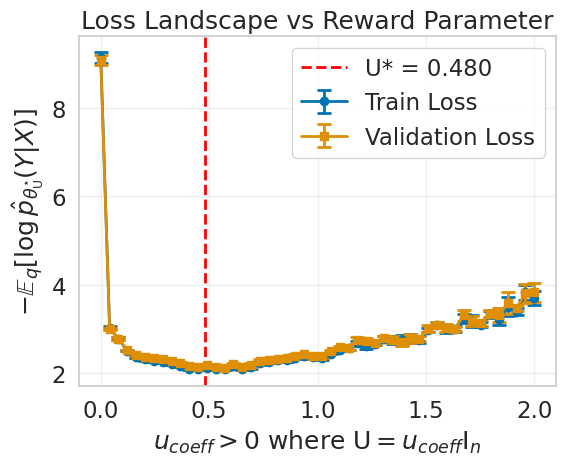

In [29]:
# Create the plot
plt.figure(figsize=(6, 5))

# Plot train loss with error bars
plt.errorbar(
    reward_init_values,
    train_means,
    yerr=train_stds,
    label="Train Loss",
    marker="o",
    capsize=5,
    capthick=2,
    linewidth=2,
)

# Plot validation loss with error bars
plt.errorbar(
    reward_init_values,
    val_means,
    yerr=val_stds,
    label="Validation Loss",
    marker="s",
    capsize=5,
    capthick=2,
    linewidth=2,
)

# Add vertical line at U_star (apply softplus if needed)
u_star_plot = np.log(1 + np.exp(U_star)) if reward_use_softplus else U_star
plt.axvline(
    x=u_star_plot,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"U* = {u_star_plot:.3f}",
)

plt.xlabel(r"$u_{coeff} > 0$ where $\mathrm{U}=u_{coeff} \mathrm{I}_n$")
plt.ylabel(r"$-\mathbb{E}_{q}[\log{\hat{p}_{\theta^{\star}_\mathrm{U}}(Y|X)}]$")
plt.title("Loss Landscape vs Reward Parameter")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()